# SupportIQ - Enterprise IT Support Agent
# Agentic RAG with Private Knowledge Base and Web Fallback

# 1. Imports & Environment Configuration

In [1]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from pinecone import Pinecone,ServerlessSpec
from langchain_pinecone import PineconeVectorStore
from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch
from langchain_core.documents import Document

from dotenv import load_dotenv

load_dotenv()


C:\Users\saura\AppData\Local\Temp\ipykernel_17476\3786064122.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
c:\FDE_Projects\SupportIQ\enterprise\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


True

# 2. Load IT Support Knowledge Base

In [2]:
loader = WebBaseLoader("https://docs.langchain.com/oss/python/langgraph/agentic-rag")
docs = loader.load()
docs

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/agentic-rag', 'title': 'Build a custom RAG agent with LangGraph - Docs by LangChain', 'description': 'Build a custom retrieval agent with LangGraph that decides when to search a vector store or respond directly.', 'language': 'en'}, page_content='Build a custom RAG agent with LangGraph - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraphBuild a custom RAG agent with LangGraphOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonLearnTutorialsDeep AgentsLangChainMulti-agentLangGraphCusto

In [3]:
print(len(docs))
print(docs[0].page_content[:1500])

1
Build a custom RAG agent with LangGraph - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraphBuild a custom RAG agent with LangGraphOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonLearnTutorialsDeep AgentsLangChainMulti-agentLangGraphCustom RAG agentCustom SQL agentConceptual overviewsLangChain vs. LangGraph vs. Deep AgentsProviders and modelsComponent architectureMemoryContextGraph APIFunctional APIAdditional resourcesUse docs programmaticallyLangChain AcademyCase studiesGet helpOn this pageConceptsSetupSet up LangSmithPreprocess documentsCreate a retriever

# 3. Document Chunking

In [4]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=150,add_start_index=True)
chunks = text_splitter.split_documents(docs)
chunks

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/agentic-rag', 'title': 'Build a custom RAG agent with LangGraph - Docs by LangChain', 'description': 'Build a custom retrieval agent with LangGraph that decides when to search a vector store or respond directly.', 'language': 'en', 'start_index': 0}, page_content="Build a custom RAG agent with LangGraph - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraphBuild a custom RAG agent with LangGraphOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonLearnTutorialsDeep AgentsLangChainMulti-ag

In [5]:
print(len(chunks))
print(chunks[0].page_content)

28
Build a custom RAG agent with LangGraph - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraphBuild a custom RAG agent with LangGraphOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonLearnTutorialsDeep AgentsLangChainMulti-agentLangGraphCustom RAG agentCustom SQL agentConceptual overviewsLangChain vs. LangGraph vs. Deep AgentsProviders and modelsComponent architectureMemoryContextGraph APIFunctional APIAdditional resourcesUse docs programmaticallyLangChain AcademyCase studiesGet helpOn this pageConceptsSetupSet up LangSmithPreprocess documentsCreate a retrieve

# 4. Embedding Model

In [6]:
embedding_model = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2-preview")
embedding_model

GoogleGenerativeAIEmbeddings(client=<google.genai.client.Client object at 0x000001199A196900>, model='gemini-embedding-2-preview', task_type=None, google_api_key=SecretStr('**********'), credentials=None, vertexai=None, project=None, location=None, base_url=None, additional_headers=None, client_args=None, api_version=None, request_options=None, output_dimensionality=None)

# 5. Pinecone Vector Database Configuration

In [7]:
INDEX_NAME = "supportiq"
NAMESPACE = "it-support-kb"

pc = Pinecone()

existing_indexes = [index_info["name"] for index_info in pc.list_indexes()]

if INDEX_NAME not in existing_indexes:

    pc.create_index(
        name=INDEX_NAME,
        dimension=3072,
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1"
        )
    )

# 6. Store Documents in Pinecone

In [8]:
vector_store = PineconeVectorStore.from_documents(
    documents=chunks,
    embedding=embedding_model,
    index_name=INDEX_NAME,
    namespace=NAMESPACE
)

# 7. Configure Knowledge Base Retriever

In [9]:
retriever = vector_store.as_retriever(
    search_kwargs = {
        "k":4,
        "namespace":NAMESPACE
    }
)

In [10]:
index = pc.Index(INDEX_NAME)

vectorstore = PineconeVectorStore(
    index=index,
    embedding=embedding_model,
    namespace=NAMESPACE
)

retriever = vector_store.as_retriever(
    search_kwargs = {
        "k":4,
        "namespace":NAMESPACE
    }
)


In [11]:
response = retriever.invoke("What is Agentic RAG")
response

[Document(id='93f6dba5-a369-48ab-9dfd-7bdff830e652', metadata={'description': 'Build a custom retrieval agent with LangGraph that decides when to search a vector store or respond directly.', 'language': 'en', 'source': 'https://docs.langchain.com/oss/python/langgraph/agentic-rag', 'start_index': 1448.0, 'title': 'Build a custom RAG agent with LangGraph - Docs by LangChain'}, page_content='LangChain offers built-in agent implementations built on LangGraph primitives. When you need deeper customization, implement the agent directly in LangGraph. This tutorial walks through one retrieval-agent pattern.\nIn this tutorial you will:'),
 Document(id='612e14e7-f11d-4292-9e95-59e2e04178f3', metadata={'description': 'Build a custom retrieval agent with LangGraph that decides when to search a vector store or respond directly.', 'language': 'en', 'source': 'https://docs.langchain.com/oss/python/langgraph/agentic-rag', 'start_index': 1448.0, 'title': 'Build a custom RAG agent with LangGraph - Docs 

# 8. LLM & Web Search Configuration

In [12]:
llm = ChatGroq(
    model="openai/gpt-oss-120b"
)

In [13]:
websearch = TavilySearch(
    max_results=5,
    topic="general",
    include_answer=True,
    include_raw_content=True
)

# 9. Agent State Definition

In [14]:
from typing import List,TypedDict, Literal
from pydantic import BaseModel, Field

In [15]:
class AgentState(TypedDict):

    question: str
    current_query: str
    kb_docs: List[Document]
    web_results: str
    kb_grade: str
    web_grade: str
    answer: str
    source_used: str
    retry_count: int

# 10. Structured Output Models

In [16]:
class RouteDecision(BaseModel):
    route: Literal["kb","direct"] = Field(
        description="Use kb for questions needing Agentic RAG docs; direct for greeting/simple chat"
    )

class EvidenceGrade(BaseModel):
    grade: Literal["good","weak"] = Field(
        description="good means evidence can answer the question; weak means not enough evidence"
    )

# 11. Query Router

In [17]:
router_llm = llm.with_structured_output(RouteDecision)

def route_question(state:AgentState):

    question = state["question"]

    decision = router_llm.invoke(f'''
You are a router for an Agentic RAG assistant.

Route to "kb" if the user asks about:
- Agentic RAG
- LangGraph Agentic RAG workflow
- retrieval grading
- query rewriting
- RAG architecture
- retriever tools
- web fallback in RAG

Route to "direct" only for greetings, thanks, or very simple conversation.

Question: {question}
''')

    print("[ROUTER]")

    return {
        "current_query":question,
        "source_used":decision.route
    }


def route_after_routing(state:AgentState) -> Literal["retrieve_kb","direct_answer"]:
    if state["source_used"] == "kb":
        return "retrieve_kb"
    return "direct_answer"

# 12. Private Knowledge Base Retrieval

In [18]:
def retrieve_kb(state:AgentState):

    query = state["current_query"]
    docs = retriever.invoke(query)
    print("[KB DOCS]")
    return {"kb_docs":docs}

# 13. Private KB Evidence Grading

In [19]:
kb_grader_llm = llm.with_structured_output(EvidenceGrade)

def grade_kb_evidence(state:AgentState):

    question = state["question"]
    context = ""

    for doc in state["kb_docs"]:
        context += f"Source:{doc.metadata.get('source')}\nContent:{doc.page_content} " + "\n\n"

    grade = kb_grader_llm.invoke(f'''
You are an evidence grader.

Question:
{question}

Private KB evidence:
{context}

Can this private KB evidence answer the question?
Return "good" if it can answer.
Return "weak" if it cannot answer or is incomplete.

''')

    print("[KB EVIDENCE ROUTER]")

    return {
        "kb_grade":grade.grade
    }


def decide_after_kb_grade(state:AgentState) -> Literal["generate_from_kb","search_web"]:
    if state["kb_grade"] == "good":
        return "generate_from_kb"
    return "search_web"

# 14. Web Search Fallback

In [20]:
def search_web(state: AgentState):

    query = state["current_query"]

    result = websearch.invoke({"query":query})

    web_results = []

    for item in result.get("results", []):
        web_results.append({
            "title": item.get("title", ""),
            "url": item.get("url", ""),
            "content": item.get("content", "")
        })

    return {
        "web_results":web_results,
        "source_used":"web"
    }
    

# 15. Web Evidence Grading

In [21]:
web_grader_llm = llm.with_structured_output(EvidenceGrade)

def grade_web_evidence(state:AgentState):

    question = state["question"]
    web_results = state["web_results"]

    grade = web_grader_llm.invoke(f'''
You are an evidence grader.

Question:
{question}

Web Search evidence:
{web_results}

Can this Web evidence answer the question?
Return "good" if it can answer.
Return "weak" if it cannot answer or is incomplete.

''')

    print("[WEB EVIDENCE ROUTER]")

    return {
        "web_grade":grade.grade
    }

MAX_RETRIES = 1

def decide_after_web_grade(state:AgentState) -> Literal["generate_from_web","rewrite_query","answer_insufficient"]:
    if state["web_grade"] == "good":
        return "generate_from_web"

    if state["retry_count"] < MAX_RETRIES:
        return "rewrite_query"

    return "answer_insufficient"

# 16. Query Rewriting

In [22]:
def rewrite_query(state:AgentState):
    question = state["question"]
    retry_count = state["retry_count"] + 1

    rewritten = llm.invoke(f"""
Rewrite the question for better retrieval and web search.

Rules:
- Preserve original intent.
- Make it specific and search-friendly.
- Do not answer.
- Return only the rewritten query.

Original question:
{question}
""").content.strip()

    print("[REWRITTEN QUERY]")

    return {
        "current_query":rewritten,
        "retry_count":retry_count
    }

# 17. Generate Answer - Private Knowledge Base

In [23]:
def generate_from_kb(state:AgentState):
    question = state["question"]

    context = ""
    
    for doc in state["kb_docs"]:
        context += f"Source:{doc.metadata.get('source')}\nContent:{doc.page_content} " + "\n\n"

    answer = llm.invoke(f"""
You are a technical instructor.

Answer using ONLY the private KB context.

Rules:
- Beginner-friendly explanation.
- Do not invent unsupported details.
- Mention that the answer is based on the private KB.
- Include source type: Private KB.

Question:
{question}

Private KB context:
{context}
""").content.strip()

    return {
        "answer":answer,
        "source_used":"private_kb"
    }

    

# 18. Generate Answer - Web Search

In [24]:
def generate_from_web(state:AgentState):

    question = state["question"]
    web_context = state["web_results"]

    answer = llm.invoke(f"""
You are a technical instructor.

The private KB was insufficient, so web search was used.

Answer using ONLY the web search context.

Rules:
- Beginner-friendly explanation.
- Do not invent unsupported details.
- Mention that the answer is based on Tavily web search.
- Include source type: Web Search.
- If URLs are present in the context, include the most useful URLs.

Question:
{question}

Web search context:
{web_context}
""").content.strip()

    return {"answer":answer,"source_used":"web"}

# 19. Direct Answer

In [25]:
def direct_answer(state:AgentState):

    question = state["question"]

    answer = llm.invoke(f"Respond Briefly and naturally.\n Message:{question}").content

    return {
        "answer":answer,
        "source_used":"direct"
    }

# 20. Insufficient Evidence Response

In [26]:
def answer_insufficient(state: AgentState):
    answer = (
        "I could not find enough reliable evidence in the private knowledge base "
        "or the web search results to answer this confidently. "
        "Please provide more specific documents or rephrase the question."
    )

    return {
        "answer": answer,
        "source_used": "insufficient_evidence",
    }

# 21. Build SupportIQ LangGraph Workflow

In [27]:
from langgraph.graph import StateGraph, START, END

In [28]:
workflow = StateGraph(AgentState)

workflow.add_node("route_question",route_question)
workflow.add_node("retrieve_kb",retrieve_kb)
workflow.add_node("grade_kb_evidence",grade_kb_evidence)
workflow.add_node("search_web",search_web)
workflow.add_node("grade_web_evidence",grade_web_evidence)
workflow.add_node("rewrite_query",rewrite_query)
workflow.add_node("generate_from_kb",generate_from_kb)
workflow.add_node("generate_from_web",generate_from_web)
workflow.add_node("direct_answer",direct_answer)
workflow.add_node("answer_insufficient",answer_insufficient)

# 22. Define Workflow Routing and Conditional Edges

In [29]:
workflow.add_edge(START,"route_question")
workflow.add_conditional_edges("route_question",route_after_routing,{"retrieve_kb":"retrieve_kb","direct_answer":"direct_answer"})
workflow.add_edge("retrieve_kb","grade_kb_evidence")
workflow.add_conditional_edges("grade_kb_evidence",decide_after_kb_grade,{"generate_from_kb":"generate_from_kb","search_web":"search_web"})
workflow.add_edge("search_web","grade_web_evidence")
workflow.add_conditional_edges("grade_web_evidence",decide_after_web_grade,{"generate_from_web":"generate_from_web","rewrite_query":"rewrite_query","answer_insufficient":"answer_insufficient"})
workflow.add_edge("rewrite_query","retrieve_kb")
workflow.add_edge("generate_from_kb",END)
workflow.add_edge("generate_from_web",END)
workflow.add_edge("direct_answer",END)
workflow.add_edge("answer_insufficient",END)

# 23. Compile SupportIQ Workflow

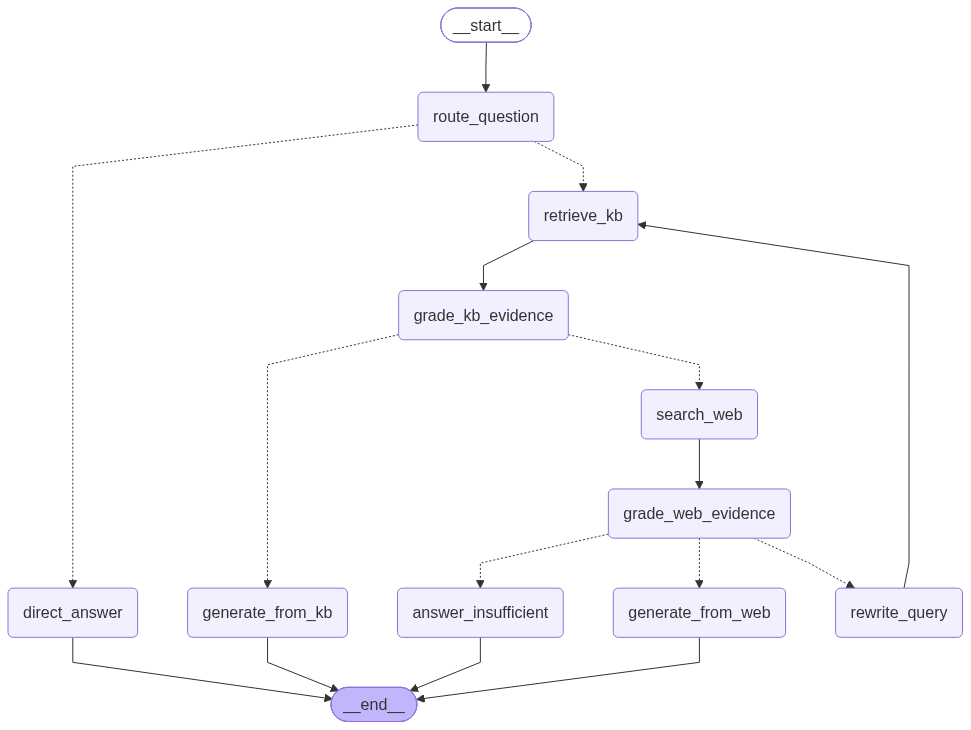

In [30]:
graph = workflow.compile()
graph

# 24. Test SupportIQ

In [31]:
response = graph.invoke({
    "question": "What is the capital of France?",
    "retry_count": 0
})

print(response["answer"])

[ROUTER]
Paris.


In [32]:
response = graph.invoke({
    "question": "What is the Agentic RAG?",
    "retry_count": 0
})

print(response["answer"])

[ROUTER]
[KB DOCS]
[KB EVIDENCE ROUTER]
**Agentic RAG** is a retrieval‑augmented generation pattern where an **agent** (a small, controllable AI component) decides **when** it should look up information from a vector store and **when** it can answer the user directly.  

In LangChain, these agents are built on top of **LangGraph primitives** – the low‑level building blocks for creating flexible, programmable workflows. The tutorial in the private knowledge base shows how to assemble such a retrieval‑agent graph, including steps like preprocessing documents, creating a retriever tool, grading documents, rewriting the question, and finally generating an answer. This lets you customize the RAG process far beyond the default “always retrieve then generate” flow.  

*Based on the private KB (LangChain documentation on Agentic RAG).*  
**Source type:** Private KB.


In [33]:
response = graph.invoke({
    "question": "What is the current version of Langchain?",
    "retry_count": 0
})

print(response["answer"])

[ROUTER]
The most recent stable release on PyPI is **LangChain 0.0.360** (published in early 2024). You can always see the latest version with:

```bash
pip install --upgrade langchain
# or
pip show langchain
```
